# 복사 평형 (Radiative Equilibrium)

이 노트북은 뉴욕 주립대학교 올버니 캠퍼스의 [Brian E. J. Rose](https://www.atmos.albany.edu/facstaff/brose/)가 작성한 [기후 실험실](https://brian-rose.github.io/ClimateLaboratoryBook)의 일부입니다.

## 1. 관측된 연평균 전지구 평균 기온 연직 분포

우리가 [복사 노트](radiation)에서 처음 접했던 NCEP 재분석 자료(Reanalysis data)에서 얻은 기온 관측 자료를 다시 살펴보겠습니다.

이 노트북에서는 나중에 여러 번 재사용할 것이기 때문에 Skew-T 다이어그램을 생성하는 함수를 정의할 것입니다.

* 코드 셀을 확장하여 Python 세부 정보를 확인하려면 클릭하세요

In [6]:
#  This code is used just to create the skew-T plot of global, annual mean air temperature
%matplotlib inline

# Install missing xarray backends if not already installed
import subprocess
import sys

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


try:
    import netCDF4
    import pydap
    import metpy
except ImportError:
    print("Installing netCDF4 and pydap...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "netCDF4", "pydap","metpy"])
    print("Installation complete. Please rerun the cell.")



from metpy.plots import SkewT

url = 'http://apdrc.soest.hawaii.edu:80/dods/public_data/Reanalysis_Data/NCEP/NCEP/clima/pressure/air'
air = xr.open_dataset(url)
## The name of the vertical axis is different than the NOAA ESRL version..
ncep_air = air.rename({'lev': 'level'})
ncep_air


#ncep_url = "http://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/ncep.reanalysis.derived/"
#time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
#ncep_air = xr.open_dataset( ncep_url + "pressure/air.mon.1981-2010.ltm.nc",
#                           decode_times=time_coder)


#  Take global, annual average
coslat = np.cos(np.deg2rad(ncep_air.lat))
weight = coslat / coslat.mean(dim='lat')
Tglobal = (ncep_air.air * weight).mean(dim=('lat','lon','time'))

Installing netCDF4 and pydap...
Installation complete. Please rerun the cell.


/usr/local/lib/python3.12/dist-packages/xarray/coding/times.py:215: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
/tmp/ipykernel_4613/2793298517.py:31: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  air = xr.open_dataset(url)


In [10]:
def make_skewT():
    fig = plt.figure(figsize=(9, 9))
    skew = SkewT(fig, rotation=30)
    skew.plot(Tglobal.level, Tglobal, color='black', linestyle='-', linewidth=2, label='Observations')
    skew.ax.set_ylim(1050, 10)
    skew.ax.set_xlim(-90, 45)
    # Add the relevant special lines
    skew.plot_dry_adiabats(linewidth=0.5)
    skew.plot_moist_adiabats(linewidth=0.5)
    #skew.plot_mixing_lines()
    skew.ax.legend()
    skew.ax.set_xlabel('Temperature (degC)', fontsize=14)
    skew.ax.set_ylabel('Pressure (hPa)', fontsize=14)
    return skew

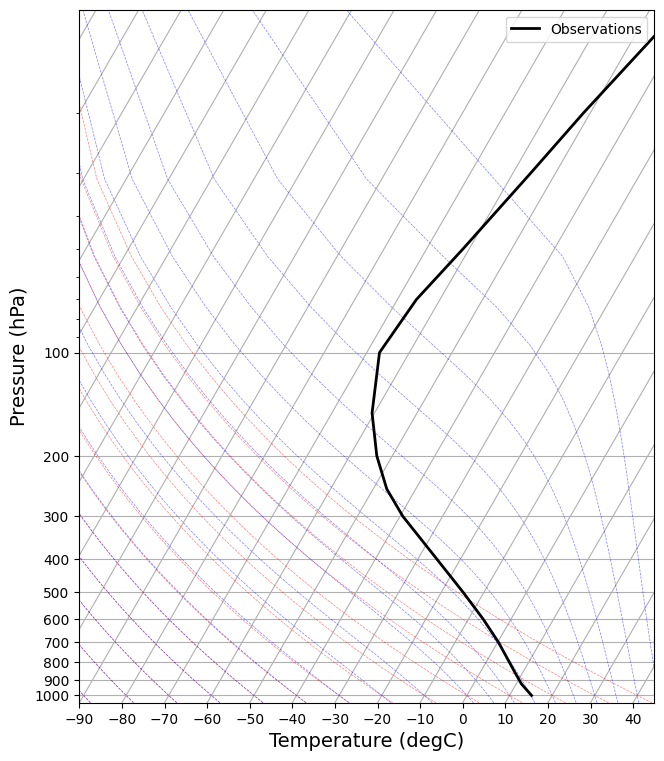

In [11]:
skew = make_skewT()

여기서는 몇 가지 상세한 **단일 열 모델(Single-Column Models)**을 사용하여 다음과 같은 질문들을 이해해보고자 합니다.

- 어떤 물리적 요인들이 실제로 이 연직 분포를 결정할까요?
- 대기 중에 다른 기체들이 존재한다면 연직 분포는 달라질까요?
- 이 연직 분포를 결정하는 데 있어 **복사(radiation)**와 **역학(dynamics)** (즉, 움직임!)의 상대적인 역할은 무엇일까요?

우리는 먼저 **복사 과정을 제외한 다른 모든 과정을 무시하고** 시작할 것입니다. 우리는 **복사 평형(radiative equilibrium)** 온도라고 불리는 것을 계산할 것입니다.

## 2. 복사 평형 -- 개념

복사 전달 모델(Radiative Transfer Models)은 대기 기둥을 일련의 층으로 나누고, 각 층 내에서 복사의 **방출**(emission)과 **흡수**(absorption)를 계산합니다.

이는 우리가 이미 살펴보았던 모델의 일반화에 불과합니다:

![층 모델의 개략도](http://www.atmos.albany.edu/facstaff/brose/classes/ENV415_Spring2018/images/2layerAtm_sketch.png)

**복사 평형(Radiative Equilibrium)**이라는 개념은 **복사(radiation)를 제외한 모든 열 교환 방식을 무시하고**, 그러한 가정 하에서 어떤 온도 분포가 존재할지 묻는 것을 의미합니다.

우리는 복사 전달 모델(radiative transfer model)을 사용하여 단파 및 장파 복사선(shortwave and longwave beams)을 명시적으로 계산하고, 에너지의 복사원과 복사 흡수원(radiative sources and sinks of energy)과 관련된 각 층의 가열/냉각을 산출함으로써 그 질문에 답할 수 있습니다.

기본적으로, 우리는 **모든 층에서 복사를 통해 에너지가 동일한 속도로 흡수되고 방출될 때** 복사 평형에 도달합니다.

복사(radiation)의 방출/흡수 특성이 파장과 다양한 기체에 복잡하게 의존하므로, 빔은 전자기 스펙트럼의 여러 다른 부분들을 나타내는 수많은 조각으로 나뉩니다.
우리는 여기서 이러한 복잡성을 명시적으로 다루지는 않겠지만, 전지구 기후 모델(GCM)에서 다루는 것과 동일한 수준의 세부사항으로 이러한 과정들을 나타내는 **모델을 사용할 것입니다**.

## 3. climlab에서 단일 열 복사 모델 구축하기

### climlab의 복사 모델

이제 우리는 **climlab**을 사용하여 다양한 기체의 스펙트럼 흡수 특성을 고려하는 **복잡한 복사 모델**을 실행할 것입니다.

climlab은 실제로 두 가지 다른 "GCM 수준"의 [복사 코드](https://climlab.readthedocs.io/en/latest/api/climlab.radiation.Radiation.html)를 제공합니다.

- NCAR에서 개발된 [CAM3 복사 모듈](https://climlab.readthedocs.io/en/latest/api/climlab.radiation.CAM3.html) (기본적으로 우리의 CESM 시뮬레이션에서 사용되는 복사 코드와 동일합니다)
- 현재 많은 GCM에서 사용되는 [RRTMG (Rapid Radiative Transfer Model)](https://climlab.readthedocs.io/en/latest/api/climlab.radiation.RRTMG.html)

위에 있는 링크들은 온라인 [climlab 문서](http://climlab.readthedocs.io/en/latest/intro.html)로 연결됩니다.

우리는 [급속 복사 전달 모델](http://rtweb.aer.com/rrtm_frame.html) 또는 RRTMG라고 불리는 모델을 사용할 것입니다. 이것은 많은 포괄적인 전지구 기후 모델(GCMs) 및 수치 일기 예보 모델에서 사용되는, "본격적이고" 널리 사용되는 복사 모델입니다.

climlab은 RRTMG 코드를 위한 사용하기 쉬운 파이썬 래퍼(Python wrapper)를 제공합니다.

### 수증기 자료

모델을 설정하기 전에, 수증기 데이터가 필요합니다. 왜일까요? 수증기는 복사적으로(radiatively) 중요한 기체이기 때문에, 우리 모델은 각 연직 고도에 얼마나 많은 수증기가 존재하는지 알아야 하기 때문입니다.

실제로는, 우리는 CESM 기준 모의실험(control simulation)의 비습장(specific humidity field)을 사용할 것입니다. 우리는 이 데이터의 전 지구적, 시간 평균을 취하고, 그 연직 프로파일(vertical profile)을 플롯할 것입니다.

In [ ]:
#  Load the model output as we have done before
cesm_data_path = "http://thredds.atmos.albany.edu:8080/thredds/dodsC/CESMA/"
# For better performance if you can access the roselab_rit filesystem (e.g. from JupyterHub)
# cesm_data_path = "/roselab_rit/cesm_archive/"
atm_control = xr.open_dataset(cesm_data_path + "cpl_1850_f19/concatenated/cpl_1850_f19.cam.h0.nc")
#  The specific humidity is stored in the variable called Q in this dataset:
atm_control.Q

<xarray.DataArray 'Q' (time: 240, lev: 26, lat: 96, lon: 144)> Size: 345MB
[86261760 values with dtype=float32]
Coordinates:
  * lev      (lev) float64 208B 3.545 7.389 13.97 23.94 ... 929.6 970.6 992.6
  * time     (time) object 2kB 0001-02-01 00:00:00 ... 0021-01-01 00:00:00
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    mdims:         1
    units:         kg/kg
    long_name:     Specific humidity
    cell_methods:  time: mean

이제 비습도(specific humidity)의 전 지구 연평균을 계산해 봅시다:

In [ ]:
# Take global, annual average of the specific humidity
weight_factor = atm_control.gw / atm_control.gw.mean(dim='lat')
Qglobal = (atm_control.Q * weight_factor).mean(dim=('lat','lon','time'))
# Take a look at what we just calculated ... it should be one-dimensional (vertical levels)
Qglobal

<xarray.DataArray (lev: 26)> Size: 208B
array([2.16104904e-06, 2.15879387e-06, 2.15121262e-06, 2.13630949e-06,
       2.12163684e-06, 2.11168002e-06, 2.09396914e-06, 2.10589390e-06,
       2.42166155e-06, 3.12595653e-06, 5.01369691e-06, 9.60746488e-06,
       2.08907654e-05, 4.78823747e-05, 1.05492451e-04, 2.11889055e-04,
       3.94176751e-04, 7.10734458e-04, 1.34192099e-03, 2.05153261e-03,
       3.16844784e-03, 4.96883408e-03, 6.62218037e-03, 8.38350326e-03,
       9.38620899e-03, 9.65030544e-03])
Coordinates:
  * lev      (lev) float64 208B 3.545 7.389 13.97 23.94 ... 929.6 970.6 992.6

그리고 그림을 생성하세요:

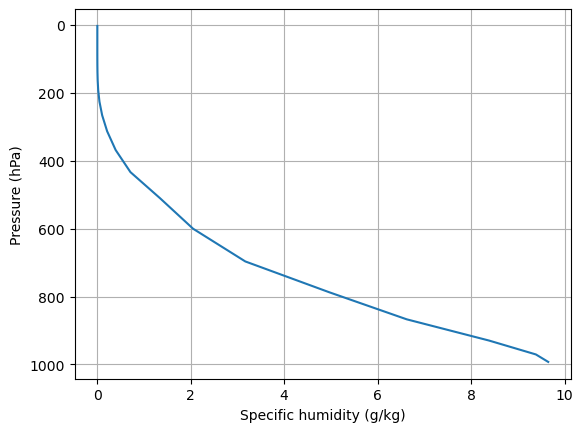

In [ ]:
fig, ax = plt.subplots()
#  Multiply Qglobal by 1000 to put in units of grams water vapor per kg of air
ax.plot(Qglobal*1000., Qglobal.lev)
ax.invert_yaxis()
ax.set_ylabel('Pressure (hPa)')
ax.set_xlabel('Specific humidity (g/kg)')
ax.grid()

이는 전형적인 기후학적 습도 분포를 보여줍니다. 수증기는 **미량 기체(trace gas)**입니다! 하지만 살펴보겠지만, 수증기는 매우 중요한 역할을 합니다.

이 그림을 바탕으로, 대부분의 수증기는 어디에 있습니까?

### 이 수증기 데이터와 동일한 격자에서 단일 열 모델을 생성합니다:

여기서 우리는 단일 열 모델을 위한 격자와 상태 변수(대기 온도 및 지표면 온도)를 생성할 것입니다.

In [ ]:
import climlab
#  Make a model on same vertical domain as the GCM
mystate = climlab.column_state(lev=Qglobal.lev, water_depth=2.5)
mystate

AttrDict({'Ts': Field([288.]), 'Tatm': Field([200.  , 203.12, 206.24, 209.36, 212.48, 215.6 , 218.72, 221.84,
       224.96, 228.08, 231.2 , 234.32, 237.44, 240.56, 243.68, 246.8 ,
       249.92, 253.04, 256.16, 259.28, 262.4 , 265.52, 268.64, 271.76,
       274.88, 278.  ])})

In [ ]:
radmodel = climlab.radiation.RRTMG(name='Radiation (all gases)',  # give our model a name!
                              state=mystate,   # give our model an initial condition!
                              specific_humidity=Qglobal.values,  # tell the model how much water vapor there is
                              albedo = 0.25,  # this the SURFACE shortwave albedo
                              timestep = climlab.constants.seconds_per_day,  # set the timestep to one day (measured in seconds)
                             )
radmodel

### 단일 열 모델 객체 탐색

우리가 방금 생성한 모델의 몇 가지 흥미로운 특성을 살펴보겠습니다.

In [ ]:
#  Here's the state dictionary we already created:
radmodel.state

AttrDict({'Ts': Field([288.]), 'Tatm': Field([200.  , 203.12, 206.24, 209.36, 212.48, 215.6 , 218.72, 221.84,
       224.96, 228.08, 231.2 , 234.32, 237.44, 240.56, 243.68, 246.8 ,
       249.92, 253.04, 256.16, 259.28, 262.4 , 265.52, 268.64, 271.76,
       274.88, 278.  ])})

In [ ]:
#  Here are the pressure levels in hPa
radmodel.lev

array([  3.544638 ,   7.3888135,  13.967214 ,  23.944625 ,  37.23029  ,
        53.114605 ,  70.05915  ,  85.439115 , 100.514695 , 118.250335 ,
       139.115395 , 163.66207  , 192.539935 , 226.513265 , 266.481155 ,
       313.501265 , 368.81798  , 433.895225 , 510.455255 , 600.5242   ,
       696.79629  , 787.70206  , 867.16076  , 929.648875 , 970.55483  ,
       992.5561   ])

`absorber_vmr`라는 딕셔너리(dictionary)가 있는데, 이 딕셔너리에는 컬럼(column) 내 모든 복사 활성 기체(radiatively active gases)의 *체적 혼합비*(volume mixing ratio)가 담겨 있습니다:

In [ ]:
radmodel.absorber_vmr

{'CO2': 0.000348,
 'CH4': 1.65e-06,
 'N2O': 3.06e-07,
 'O2': 0.21,
 'CFC11': 0.0,
 'CFC12': 0.0,
 'CFC22': 0.0,
 'CCL4': 0.0,
 'O3': array([7.52507018e-06, 8.51545793e-06, 7.87041289e-06, 5.59601020e-06,
        3.46128454e-06, 2.02820936e-06, 1.13263102e-06, 7.30182697e-07,
        5.27326553e-07, 3.83940962e-07, 2.82227214e-07, 2.12188506e-07,
        1.62569291e-07, 1.17991442e-07, 8.23582543e-08, 6.25738219e-08,
        5.34457156e-08, 4.72688637e-08, 4.23614749e-08, 3.91392482e-08,
        3.56025264e-08, 3.12026770e-08, 2.73165152e-08, 2.47190016e-08,
        2.30518624e-08, 2.22005071e-08])}

대부분의 값은 대기 중에서 **잘 혼합되어** 있다고 가정되기 때문에 단일 값으로 표현됩니다.

예외는 오존인데, 오존은 관측 자료로부터 얻은 수직 구조를 가집니다. 이를 한번 그려봅시다.

In [ ]:
#  E.g. the CO2 content (a well-mixed gas) in parts per million
radmodel.absorber_vmr['CO2'] * 1E6

348.0

### 파이썬 실습: 오존 연직 분포 플로팅

방금 위에서 만들었던 비습(specific humidity) 그래프와 유사하게, 오존의 연직 구조를 보여주는 간단한 그래프를 그리세요.

In [ ]:
# here is the data you need for the plot, as a plain numpy arrays:
print(radmodel.lev)
print(radmodel.absorber_vmr['O3'])

[  3.544638    7.3888135  13.967214   23.944625   37.23029    53.114605
  70.05915    85.439115  100.514695  118.250335  139.115395  163.66207
 192.539935  226.513265  266.481155  313.501265  368.81798   433.895225
 510.455255  600.5242    696.79629   787.70206   867.16076   929.648875
 970.55483   992.5561   ]
[7.52507018e-06 8.51545793e-06 7.87041289e-06 5.59601020e-06
 3.46128454e-06 2.02820936e-06 1.13263102e-06 7.30182697e-07
 5.27326553e-07 3.83940962e-07 2.82227214e-07 2.12188506e-07
 1.62569291e-07 1.17991442e-07 8.23582543e-08 6.25738219e-08
 5.34457156e-08 4.72688637e-08 4.23614749e-08 3.91392482e-08
 3.56025264e-08 3.12026770e-08 2.73165152e-08 2.47190016e-08
 2.30518624e-08 2.22005071e-08]


다른 복사적으로 중요한 기체는 물론 수증기이며, 이는 `specific_humidity` 속성에 별도로 저장됩니다.

In [ ]:
#  specific humidity in kg/kg, on the same pressure axis
radmodel.specific_humidity

array([2.16104904e-06, 2.15879387e-06, 2.15121262e-06, 2.13630949e-06,
       2.12163684e-06, 2.11168002e-06, 2.09396914e-06, 2.10589390e-06,
       2.42166155e-06, 3.12595653e-06, 5.01369691e-06, 9.60746488e-06,
       2.08907654e-05, 4.78823747e-05, 1.05492451e-04, 2.11889055e-04,
       3.94176751e-04, 7.10734458e-04, 1.34192099e-03, 2.05153261e-03,
       3.16844784e-03, 4.96883408e-03, 6.62218037e-03, 8.38350326e-03,
       9.38620899e-03, 9.65030544e-03])

### RRTMG 복사 모델은 다양한 입력 매개변수(input parameters)를 가집니다.

자세한 내용은 [문서](http://climlab.readthedocs.io/en/latest/api/climlab.radiation.Radiation.html)를 참고하실 수 있습니다.

In [ ]:
for item in radmodel.input:
    print(item)

specific_humidity
absorber_vmr
cldfrac
clwp
ciwp
r_liq
r_ice
emissivity
S0
coszen
irradiance_factor
aldif
aldir
asdif
asdir
icld
irng
idrv
permuteseed_sw
permuteseed_lw
dyofyr
inflgsw
inflglw
iceflgsw
iceflglw
liqflgsw
liqflglw
tauc_sw
tauc_lw
ssac_sw
asmc_sw
fsfc_sw
tauaer_sw
ssaaer_sw
asmaer_sw
ecaer_sw
tauaer_lw
isolvar
indsolvar
bndsolvar
solcycfrac


많은 매개변수들이 구름의 **복사 효과(radiative effects)**를 제어합니다.

단, 여기서 주목해야 할 점은 모델이 **구름이 전혀 없는 상태로 초기화된다**는 것입니다.

In [ ]:
#  This is the fractional area covered by clouds in our column:
radmodel.cldfrac

0.0

## 4. 단일열 모델에서의 복사 평형

### 모델의 시간을 진행시키세요!

현재 기온은 다음과 같습니다 (초기 조건):

In [ ]:
radmodel.Ts

Field([288.])

In [ ]:
radmodel.Tatm

Field([200.  , 203.12, 206.24, 209.36, 212.48, 215.6 , 218.72, 221.84,
       224.96, 228.08, 231.2 , 234.32, 237.44, 240.56, 243.68, 246.8 ,
       249.92, 253.04, 256.16, 259.28, 262.4 , 265.52, 268.64, 271.76,
       274.88, 278.  ])

이제 단일 시간 단계를 진행해봅시다:

In [ ]:
radmodel.step_forward()

In [ ]:
radmodel.Ts

Field([288.57727148])

표면이 더 따뜻해졌습니다!

해당 타임스텝(timestep) 동안 생성된 모든 진단 정보를 살펴보겠습니다:

### 단일 열 모델의 진단 변수

모든 climlab 모델에는 `diagnostics` 사전이 있습니다. 여기서는 이를 `xarray` 데이터셋으로 확인해 볼 것입니다:


In [ ]:
climlab.to_xarray(radmodel.diagnostics)

<xarray.Dataset> Size: 4kB
Dimensions:           (depth: 1, lev: 26, lev_bounds: 27, depth_bounds: 2)
Coordinates:
  * depth             (depth) float64 8B 1.25
  * lev               (lev) float64 208B 3.545 7.389 13.97 ... 929.6 970.6 992.6
  * depth_bounds      (depth_bounds) float64 16B 0.0 2.5
  * lev_bounds        (lev_bounds) float64 216B 0.0 5.467 10.68 ... 981.6 1e+03
Data variables: (12/26)
    OLR               (depth) float64 8B 251.0
    OLRclr            (depth) float64 8B 251.0
    OLRcld            (depth) float64 8B 0.0
    TdotLW            (lev) float64 208B -1.505 -0.8463 ... -0.1981 1.523
    TdotLW_clr        (lev) float64 208B -1.505 -0.8463 ... -0.1981 1.523
    LW_sfc            (depth) float64 8B 93.93
    ...                ...
    SW_flux_up        (lev_bounds) float64 216B 86.52 86.35 86.24 ... 54.9 54.59
    SW_flux_down      (lev_bounds) float64 216B 341.3 335.3 ... 220.3 218.4
    SW_flux_net       (lev_bounds) float64 216B 254.8 248.9 ... 165.4 163.8
    SW_flux_up_clr    (lev_bounds) float64 216B 86.52 86.35 86.24 ... 54.9 54.59
    SW_flux_down_clr  (lev_bounds) float64 216B 341.3 335.3 ... 220.3 218.4
    SW_flux_net_clr   (lev_bounds) float64 216B 254.8 248.9 ... 165.4 163.8

복사 전달 모델(radiative transfer model)의 주된 역할은 각 모델 층 사이에서 상향 및 하향 단파 복사 플럭스(shortwave flux)와 장파 복사 플럭스(longwave flux)를 계산하는 것입니다.

예를 들어:

In [ ]:
climlab.to_xarray(radmodel.LW_flux_up)

<xarray.DataArray (lev_bounds: 27)> Size: 216B
Field([251.01459806, 251.25313801, 251.62168892, 252.36094038,
       253.49760842, 254.94148495, 256.51042674, 257.95176838,
       259.23376945, 260.55457866, 261.96972717, 263.51365698,
       265.24255886, 267.2270195 , 269.61795334, 272.55968463,
       276.15994067, 280.45320896, 285.55601094, 291.88950856,
       299.3801653 , 308.24370169, 319.18061254, 331.81032106,
       346.00223519, 360.37156583, 390.0990181 ])
Coordinates:
  * lev_bounds  (lev_bounds) float64 216B 0.0 5.467 10.68 ... 950.1 981.6 1e+03

이것들은 W/m2 단위의 상향 장파 복사 플럭스(upward longwave fluxes)입니다.

모델에는 26개의 기압층(pressure levels)이 있는데, 왜 27개의 데이터 포인트(data points)가 있나요?

In [ ]:
radmodel.lev

array([  3.544638 ,   7.3888135,  13.967214 ,  23.944625 ,  37.23029  ,
        53.114605 ,  70.05915  ,  85.439115 , 100.514695 , 118.250335 ,
       139.115395 , 163.66207  , 192.539935 , 226.513265 , 266.481155 ,
       313.501265 , 368.81798  , 433.895225 , 510.455255 , 600.5242   ,
       696.79629  , 787.70206  , 867.16076  , 929.648875 , 970.55483  ,
       992.5561   ])

In [ ]:
radmodel.lev_bounds

array([   0.        ,    5.46672575,   10.67801375,   18.9559195 ,
         30.5874575 ,   45.1724475 ,   61.5868775 ,   77.7491325 ,
         92.976905  ,  109.382515  ,  128.682865  ,  151.3887325 ,
        178.1010025 ,  209.5266    ,  246.49721   ,  289.99121   ,
        341.1596225 ,  401.3566025 ,  472.17524   ,  555.4897275 ,
        648.660245  ,  742.249175  ,  827.43141   ,  898.4048175 ,
        950.1018525 ,  981.555465  , 1000.        ])

플럭스 배열의 마지막 요소는 **지표면에서 첫 번째 층으로 향하는 상향 플럭스(upward flux)**를 나타냅니다.

In [ ]:
radmodel.LW_flux_up[-1]

np.float64(390.0990181032836)

그 값은 약 390 W m$^{-2}$입니다.

왜 그럴까요?

In [ ]:
sigma = 5.67E-8
sigma * 288**4

390.0793946112

지표면 온도는 288 K로 초기화되었으며, 모델에서는 지표면이 흑체(blackbody)에 매우 가깝게 처리됩니다.

최상층(top layer)에서 우주 공간으로 나가는 플럭스는 어떻게 될까요?

이 정보에 접근하는 두 가지 방법:

In [ ]:
radmodel.LW_flux_up[0]

np.float64(251.01459805907507)

In [ ]:
radmodel.OLR

Field([251.01459806])

물론 단파 복사(shortwave radiation)에 대해서는 완전히 다른 종류의 플럭스들이 존재합니다.

우리가 자주 살펴보고 싶어 할 진단 지표 중 하나는 바로 **대기 상단(TOA) 순 에너지 수지(net energy budget at the top of the atmosphere)**입니다:

In [ ]:
radmodel.ASR - radmodel.OLR

Field([3.76767763])

***모델이 에너지를 얻고 있나요, 아니면 잃고 있나요?***

### 평형 상태까지 모델 진행

여기서는 모델이 에너지 평형(energy balance)에 매우 근접할 때까지 시간적으로 진행시키고자 합니다.

우리는 대기 상단 에너지 불균형(top-of-atmosphere imbalance)을 조건으로 `while` 반복문을 사용할 수 있습니다:

In [ ]:
while np.abs(radmodel.ASR - radmodel.OLR) > 0.01:
    radmodel.step_forward()

에너지 수지를 다시 확인해봅시다:

In [ ]:
#  Check the energy budget again
radmodel.ASR - radmodel.OLR

Field([0.00988074])

실제로, 그 불균형은 이제 작다.

### 복사 평형 온도를 관측값과 비교하기

다음은 우리의 skew-T 플롯에 모델 기온 프로파일을 추가하는 데 사용할 도우미 함수입니다.

In [ ]:
def add_profile(skew, model, linestyle='-', color=None):
    line = skew.plot(model.lev, model.Tatm - climlab.constants.tempCtoK,
             label=model.name, linewidth=2)[0]
    skew.plot(1000, model.Ts - climlab.constants.tempCtoK, 'o',
              markersize=8, color=line.get_color())
    skew.ax.legend()

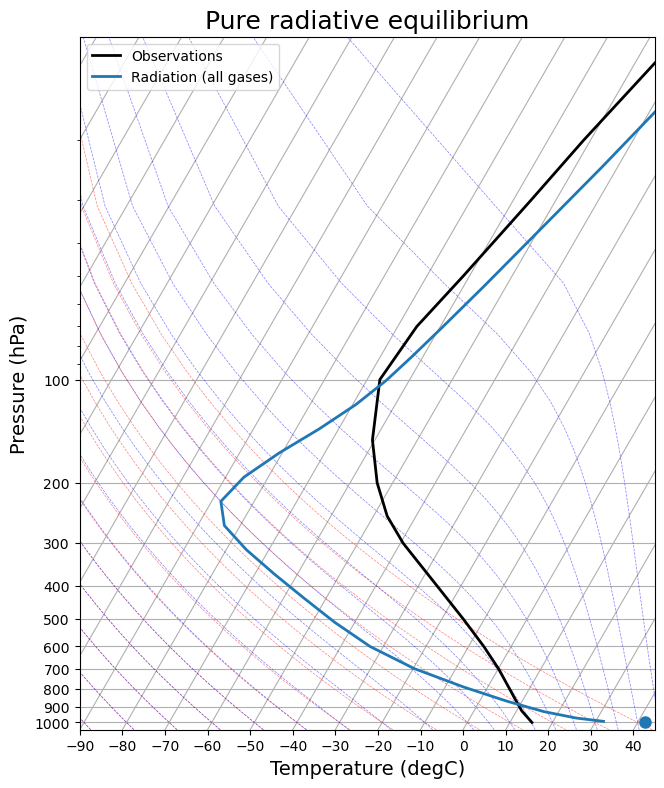

In [ ]:
skew = make_skewT()
add_profile(skew, radmodel)
skew.ax.set_title('Pure radiative equilibrium', fontsize=18);

이 모델-자료 비교에 대해 어떻게 생각하세요?

## 5. 다양한 기체들이 복사 평형 프로파일 (radiative equilibrium profile)에 미치는 영향

**모델은 실험하고 탐구하는 도구입니다!**

우리는 방금 여러 가지 다른 흡수 기체를 포함하는 단일 열 복사 모델을 구축했습니다. *우리는 이들을 제거함으로써 그들의 영향을 파악할 수 있습니다.*

### 수증기가 없는 복사 평형 (Radiative equilibrium)

In [ ]:
# Make an exact clone of our existing model
radmodel_noH2O = climlab.process_like(radmodel)
radmodel_noH2O.name = 'Radiation (no H2O)'
radmodel_noH2O

In [ ]:
#  Here is the water vapor profile we started with
radmodel_noH2O.specific_humidity

array([2.16104904e-06, 2.15879387e-06, 2.15121262e-06, 2.13630949e-06,
       2.12163684e-06, 2.11168002e-06, 2.09396914e-06, 2.10589390e-06,
       2.42166155e-06, 3.12595653e-06, 5.01369691e-06, 9.60746488e-06,
       2.08907654e-05, 4.78823747e-05, 1.05492451e-04, 2.11889055e-04,
       3.94176751e-04, 7.10734458e-04, 1.34192099e-03, 2.05153261e-03,
       3.16844784e-03, 4.96883408e-03, 6.62218037e-03, 8.38350326e-03,
       9.38620899e-03, 9.65030544e-03])

이제 물을 완전히 없애세요!

In [ ]:
radmodel_noH2O.specific_humidity *= 0.

In [ ]:
radmodel_noH2O.specific_humidity

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0.])

그리고 이 새로운 모델을 평형(equilibrium)에 도달할 때까지 실행합니다:

In [ ]:
#  it's useful to take a single step first before starting the while loop
#   because the diagnostics won't get updated
#  (and thus show the effects of removing water vapor)
#  until we take a step forward
radmodel_noH2O.step_forward()
while np.abs(radmodel_noH2O.ASR - radmodel_noH2O.OLR) > 0.01:
    radmodel_noH2O.step_forward()

In [ ]:
radmodel_noH2O.ASR - radmodel_noH2O.OLR

Field([-0.00999903])

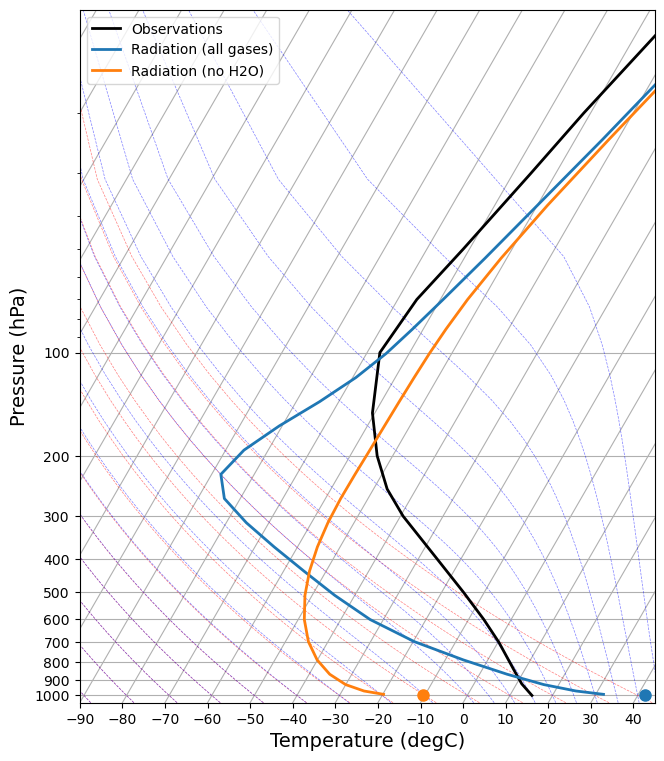

In [ ]:
skew = make_skewT()
for model in [radmodel, radmodel_noH2O]:
    add_profile(skew, model)

이를 통해 수증기의 복사 역할에 대해 무엇을 배울 수 있다고 생각하나요?

### 실습: 오존이 없는 복사 평형

위 단계를 따라서 또 다른 모델을 만드세요. 하지만 이번에는 수증기를 제거하는 대신 오존을 제거하세요!

세 가지 모델 결과를 모두 비교하는 또 다른 skew-T 도표를 그려보세요.

시간이 있다면, 수증기와 오존을 모두 제거하는 세 번째 경우를 시도해보세요!

## 6. 복사 평형 결과 요약

- 저희는 흡수 기체의 지정된 프로파일을 사용하여 RRTMG 복사 모델로 **순수 복사 평형(pure radiative equilibrium)** 온도 프로파일을 계산했습니다.
- 복사 평형(Radiative Equilibrium)이란 **복사가 층간 에너지를 전달할 수 있는 유일한 물리적 과정일 경우** 지표면과 대기 기둥이 가질 온도들을 의미합니다.
- 저희는 주요 흡수 기체의 유무에 따라 여러 가지 다른 복사 평형 프로파일을 계산했습니다.
    - 수증기가 없는 프로파일은 **지표면과 하층 대류권에서 훨씬 더 차갑지만**, 성층권에서는 거의 동일합니다.
    - 오존이 없는 프로파일은 **성층권에서 훨씬 더 차갑지만**, 지표면 근처에서는 거의 동일합니다.
    - 사실 오존이 없으면 성층권 자체가 존재하지 않습니다! 해당 프로파일에서는 상층 대기의 온도가 거의 등온(isothermal) 상태입니다.

하지만 정말 핵심적인 시사점은 이러한 복사 평형 프로파일(radiative equilibrium profiles) 중 어떤 것도 대류권에서 관측되는 결과와 크게 일치하지 않는다는 것입니다.

이는 (복사 외의) 다른 물리적 과정들이 관측된 온도 프로파일(temperature profile)을 결정하는 데 중요함을 강력히 시사합니다.

스큐-T 도표(skew-T diagram)에 나타내면 **모든 복사 평형(radiative equilibrium) 연직 기온 분포(profiles)가 지표면 근처에서 정적으로 불안정하다**는 점이 명확해집니다.

따라서 다음 단계는 대류 혼합(convective mixing)이 지표면(surface)과 하층 대류권(lower troposphere)의 온도에 미치는 영향을 살펴보는 것입니다.

## 출처

이 노트북은 University at Albany 소속 [Brian E. J. Rose](https://www.atmos.albany.edu/facstaff/brose/)가 개발하고 유지보수하는 오픈 소스 교재인 `[The Climate Laboratory](https://brian-rose.github.io/ClimateLaboratoryBook)`의 일부입니다.

이 자료는 `[Creative Commons Attribution 4.0 International (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/)` 라이선스에 따라 무료 및 자유로운 이용을 위해 허가되었습니다.

본 자료와 `[climlab 소프트웨어](https://github.com/climlab/climlab)`의 개발은 Brian Rose에게 수여된 국립과학재단(National Science Foundation)의 AGS-1455071 과제 번호(award)를 통해 부분적으로 지원받고 있습니다. 여기에 표현된 모든 의견, 연구 결과, 결론 또는 권고 사항은 저의 것이며, 반드시 국립과학재단(National Science Foundation)의 견해를 반영하는 것은 아닙니다.